# Quick-Commerce Operations — Beginner Python & Pandas EDA

This notebook contains only the essential steps you should learn first.

**Flow:** Load data → check quality → calculate KPIs → group data → create charts → explain insights

> The dataset is synthetic and is not actual Flipkart data.


## 1. Import libraries

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt

# Create an output folder
os.makedirs("outputs", exist_ok=True)

## 2. Load the data

In [2]:
orders = pd.read_csv("data/orders_clean.csv")

print("Number of rows and columns:", orders.shape)
print("\nFirst 5 rows:")
print(orders.head())

Number of rows and columns: (25000, 47)

First 5 rows:
     order_id  order_date  ... cancellation_reason  customer_rating
0  ORD0000001  2026-05-27  ...                 NaN              4.5
1  ORD0000002  2026-04-20  ...                 NaN              3.4
2  ORD0000003  2026-04-13  ...    Item Unavailable              NaN
3  ORD0000004  2026-05-23  ...                 NaN              3.3
4  ORD0000005  2026-05-26  ...                 NaN              3.6

[5 rows x 47 columns]


## 3. Check data quality

Check the data before starting the analysis.

In [3]:
print("\nMissing values:")
print(orders.isnull().sum().sort_values(ascending=False).head(10))

print("\nDuplicate order IDs:")
print(orders.duplicated(subset="order_id").sum())

# Convert the date column from text to date
orders["order_date"] = pd.to_datetime(orders["order_date"])


Missing values:
cancelled_timestamp         23246
cancellation_stage          23246
cancellation_reason         23246
delivered_timestamp          1754
rider_id                     1754
rider_assigned_timestamp     1754
actual_delivery_minutes      1754
travel_minutes               1754
dispatch_timestamp           1754
packing_minutes              1754
dtype: int64

Duplicate order IDs:
0


## 4. Calculate overall KPIs

Use simple filtering and arithmetic to calculate business KPIs.

In [4]:
completed_orders = orders[
    ~orders["order_status"].isin(["Cancelled", "Payment Failed"])
]

cancelled_orders = orders[orders["order_status"] == "Cancelled"]

sla_orders = orders[
    orders["sla_status"].isin(["Within SLA", "SLA Breach"])
]

on_time_orders = orders[orders["sla_status"] == "Within SLA"]

total_orders = len(orders)
fulfilment_rate = len(completed_orders) / total_orders * 100
cancellation_rate = len(cancelled_orders) / total_orders * 100
on_time_rate = len(on_time_orders) / len(sla_orders) * 100
average_delivery_time = orders["actual_delivery_minutes"].mean()
average_order_value = orders["gross_order_value"].mean()

print("\n--- OVERALL KPIs ---")
print("Total orders:", total_orders)
print("Fulfilment rate:", round(fulfilment_rate, 2), "%")
print("Cancellation rate:", round(cancellation_rate, 2), "%")
print("On-time delivery rate:", round(on_time_rate, 2), "%")
print("Average delivery time:", round(average_delivery_time, 2), "minutes")
print("Average order value:", round(average_order_value, 2))


--- OVERALL KPIs ---
Total orders: 25000
Fulfilment rate: 92.98 %
Cancellation rate: 5.9 %
On-time delivery rate: 80.9 %
Average delivery time: 24.9 minutes
Average order value: 1137.72


## 5. Analyze order status


--- ORDERS BY STATUS ---
order_status
Delivered              20366
Partially Delivered     2618
Cancelled               1476
Payment Failed           278
Returned                 262
Name: count, dtype: int64


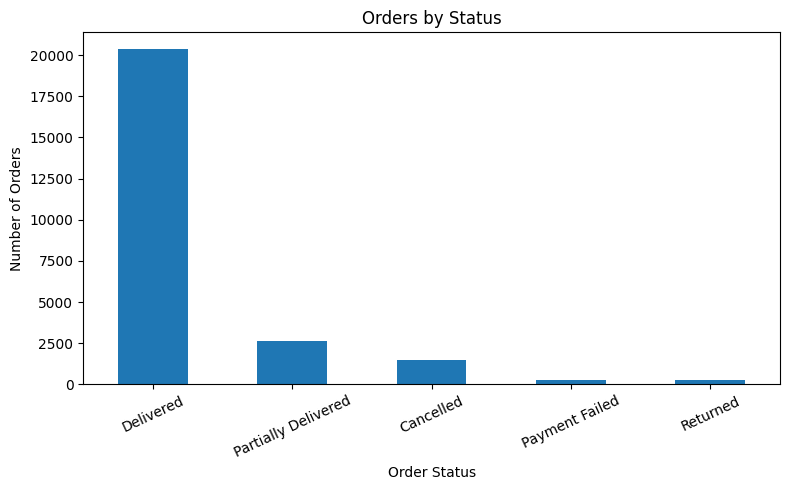

In [5]:
status_summary = orders["order_status"].value_counts()

print("\n--- ORDERS BY STATUS ---")
print(status_summary)

status_summary.plot(kind="bar", figsize=(8, 5))
plt.title("Orders by Status")
plt.xlabel("Order Status")
plt.ylabel("Number of Orders")
plt.xticks(rotation=25)
plt.tight_layout()
plt.savefig("outputs/orders_by_status.png")
plt.show()
plt.close()

## 6. Analyze daily order trend


--- DAILY ORDERS ---
order_date
2026-04-01    281
2026-04-02    253
2026-04-03    275
2026-04-04    308
2026-04-05    292
Name: order_id, dtype: int64


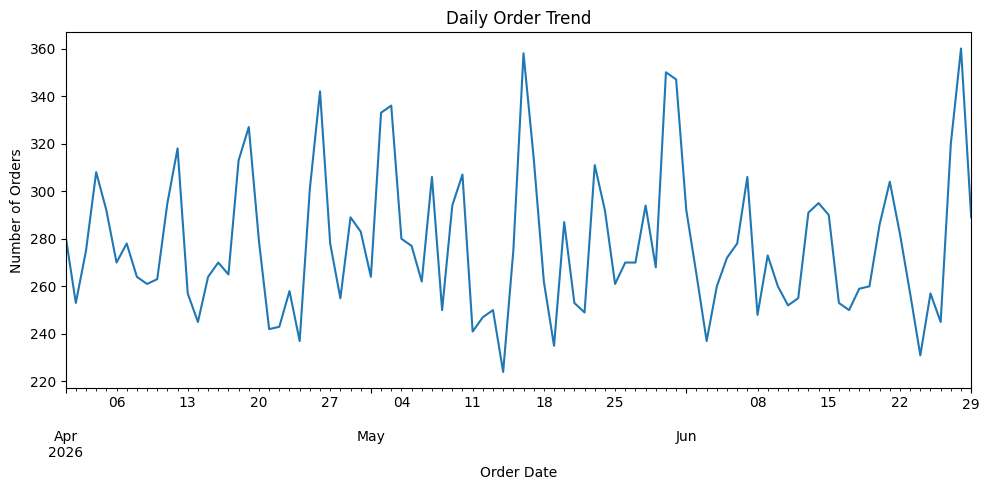

In [6]:
daily_orders = orders.groupby("order_date")["order_id"].count()

print("\n--- DAILY ORDERS ---")
print(daily_orders.head())

daily_orders.plot(kind="line", figsize=(10, 5))
plt.title("Daily Order Trend")
plt.xlabel("Order Date")
plt.ylabel("Number of Orders")
plt.tight_layout()
plt.savefig("outputs/daily_order_trend.png")
plt.show()
plt.close()

## 7. Analyze performance by city

`groupby()` creates one summary row for each city.


--- CITY PERFORMANCE ---
        city  total_orders  ...  cancellation_rate  on_time_rate
5       Pune          2830  ...               7.03         77.73
0  Bengaluru          7040  ...               5.98         79.96
4     Mumbai          3956  ...               5.94         81.22
2  Delhi NCR          4266  ...               5.81         82.25
3  Hyderabad          3836  ...               5.55         82.32
1    Chennai          3072  ...               5.21         81.85

[6 rows x 8 columns]


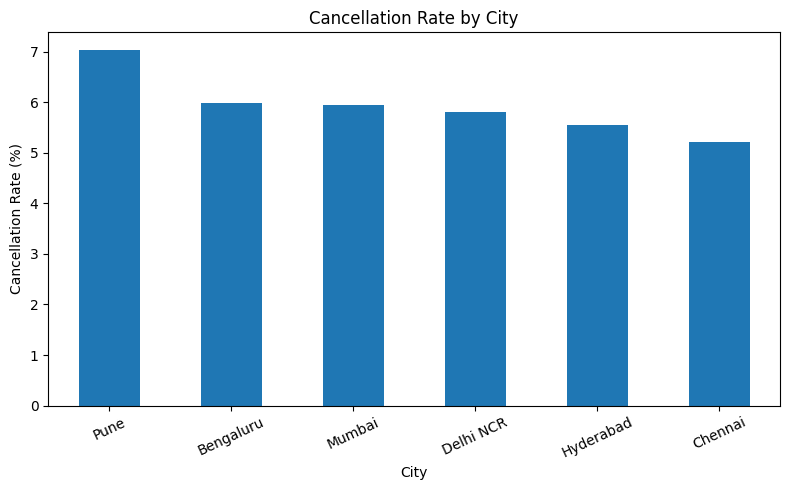

In [7]:
orders["cancelled_flag"] = (
    orders["order_status"] == "Cancelled"
).astype(int)

orders["on_time_flag"] = (
    orders["sla_status"] == "Within SLA"
).astype(int)

orders["sla_flag"] = (
    orders["sla_status"].isin(["Within SLA", "SLA Breach"])
).astype(int)

city_summary = orders.groupby("city").agg({
    "order_id": "count",
    "cancelled_flag": "sum",
    "on_time_flag": "sum",
    "sla_flag": "sum",
    "actual_delivery_minutes": "mean"
}).reset_index()

city_summary = city_summary.rename(columns={
    "order_id": "total_orders",
    "actual_delivery_minutes": "average_delivery_minutes"
})

city_summary["cancellation_rate"] = (
    city_summary["cancelled_flag"]
    / city_summary["total_orders"]
    * 100
)

city_summary["on_time_rate"] = (
    city_summary["on_time_flag"]
    / city_summary["sla_flag"]
    * 100
)

city_summary = city_summary.round(2)
city_summary = city_summary.sort_values(
    "cancellation_rate", ascending=False
)

print("\n--- CITY PERFORMANCE ---")
print(city_summary)

city_summary.to_csv("outputs/city_performance.csv", index=False)

city_summary.plot(
    x="city",
    y="cancellation_rate",
    kind="bar",
    figsize=(8, 5),
    legend=False
)
plt.title("Cancellation Rate by City")
plt.xlabel("City")
plt.ylabel("Cancellation Rate (%)")
plt.xticks(rotation=25)
plt.tight_layout()
plt.savefig("outputs/cancellation_rate_by_city.png")
plt.show()
plt.close()

## 8. Compare peak and non-peak hours

In [8]:
orders["time_type"] = orders["peak_hour_flag"].replace({
    "Y": "Peak Hour",
    "N": "Non-Peak Hour"
})

peak_summary = orders.groupby("time_type").agg({
    "order_id": "count",
    "cancelled_flag": "sum",
    "on_time_flag": "sum",
    "sla_flag": "sum",
    "actual_delivery_minutes": "mean"
}).reset_index()

peak_summary = peak_summary.rename(columns={
    "order_id": "total_orders",
    "actual_delivery_minutes": "average_delivery_minutes"
})

peak_summary["cancellation_rate"] = (
    peak_summary["cancelled_flag"]
    / peak_summary["total_orders"]
    * 100
)

peak_summary["on_time_rate"] = (
    peak_summary["on_time_flag"]
    / peak_summary["sla_flag"]
    * 100
)

peak_summary = peak_summary.round(2)

print("\n--- PEAK VS NON-PEAK ---")
print(peak_summary)

peak_summary.to_csv("outputs/peak_vs_non_peak.csv", index=False)


--- PEAK VS NON-PEAK ---
       time_type  total_orders  ...  cancellation_rate  on_time_rate
0  Non-Peak Hour         10420  ...               4.63         93.49
1      Peak Hour         14580  ...               6.82         71.67

[2 rows x 8 columns]


## 9. Find the main cancellation reasons


--- CANCELLATION REASONS ---
   cancellation_reason  cancelled_orders
0     Item Unavailable               440
1   Customer Cancelled               427
2  No Delivery Partner               206
3       Store Overload               161
4        Address Issue               140
5         System Issue               102


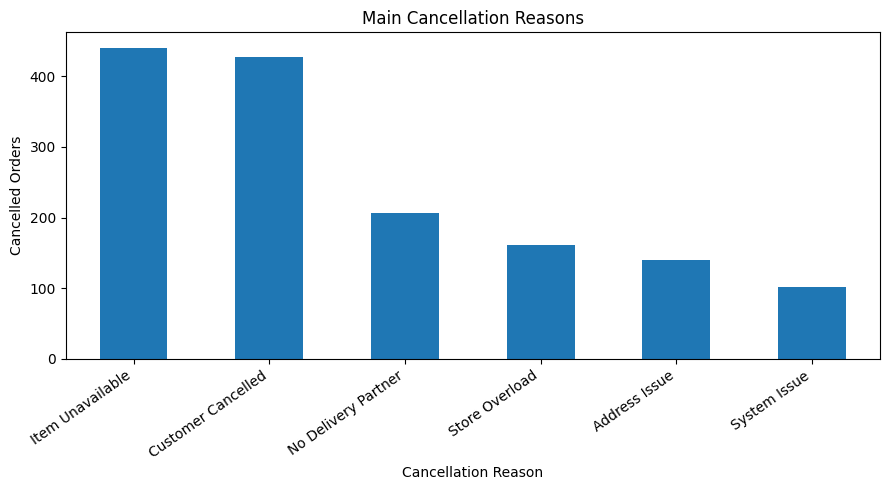

In [9]:
cancellation_reasons = (
    cancelled_orders["cancellation_reason"]
    .value_counts()
    .reset_index()
)

cancellation_reasons.columns = [
    "cancellation_reason",
    "cancelled_orders"
]

print("\n--- CANCELLATION REASONS ---")
print(cancellation_reasons)

cancellation_reasons.to_csv(
    "outputs/cancellation_reasons.csv",
    index=False
)

cancellation_reasons.plot(
    x="cancellation_reason",
    y="cancelled_orders",
    kind="bar",
    figsize=(9, 5),
    legend=False
)
plt.title("Main Cancellation Reasons")
plt.xlabel("Cancellation Reason")
plt.ylabel("Cancelled Orders")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.savefig("outputs/cancellation_reasons.png")
plt.show()
plt.close()

## 10. Print simple insights

Convert the analysis into clear business statements.

In [10]:
weakest_city = city_summary.iloc[0]
main_reason = cancellation_reasons.iloc[0]

peak_row = peak_summary[
    peak_summary["time_type"] == "Peak Hour"
].iloc[0]

non_peak_row = peak_summary[
    peak_summary["time_type"] == "Non-Peak Hour"
].iloc[0]

print("\n--- BUSINESS INSIGHTS ---")
print(
    "1.", weakest_city["city"],
    "has the highest cancellation rate at",
    weakest_city["cancellation_rate"], "%"
)

print(
    "2. Peak-hour on-time delivery is",
    peak_row["on_time_rate"], "% compared with",
    non_peak_row["on_time_rate"], "% during non-peak hours."
)

print(
    "3. The main cancellation reason is",
    main_reason["cancellation_reason"],
    "with", main_reason["cancelled_orders"], "orders."
)

print("\nEDA completed successfully.")


--- BUSINESS INSIGHTS ---
1. Pune has the highest cancellation rate at 7.03 %
2. Peak-hour on-time delivery is 71.67 % compared with 93.49 % during non-peak hours.
3. The main cancellation reason is Item Unavailable with 440 orders.

EDA completed successfully.


## How to explain this in an interview

> I loaded the order dataset using Pandas and checked missing values and duplicate order IDs. I calculated fulfilment, cancellation, on-time delivery, average delivery time, and average order value. I then used filtering and groupby analysis to compare performance by city and peak hour. Finally, I investigated cancellation reasons, created charts, and converted the results into operational recommendations.
